{
    'topic': '三毛猫',
    'poem': '## 
三毛猫の午後\n\n日溜まりは、きょうも三色に熟れる\nしろ、くろ、あか。まだらに呼吸する獣の背で\n十二月の光が、ゆっく
りと粒になる\n\n迷子の影が、壁を這う\nだれも知らない合図を、しっぽの先で\n編みながら、きみは眠る\n\n世界は、あまり
に多い色彩に溢れて\nときに、目の奥でちらつくけれど\nきみの毛皮に触れるたび\n色は、ようやく名前を持つのだ\n\nしろ、
くろ、あか。刻まれた三つのきおく\nそれぞれの裏側に、しずかな喪失を\nまばたきに抱いて、きみは\n\nまた、なにかのまわ
りをぐるりと回る\nそれはきっと、だれかの吐息の温度\nぽっかりと、この部屋に残された時間\n\n硝子戸の向こう、暮れかか
る空が\nきみという一匹の宇宙を映す\nしろが溶け、くろが滲み、あかが哭く\n\nめくるめく夕暮れの隙間で\nきみは小さく伸
びをして\nやがて、さよならも挨拶もなく\nしろ、くろ、あか。また生まれ変わる',
    'joke': 
'三毛猫（三色毛の猫）に関するジョーク（ダジャレや言葉遊び）をいくつかご紹介しますね。\n\n---\n\n**その1：お店での会
話**\n三毛猫が八百屋に入ってきました。\n店員：「いらっしゃいませ！何をお探しですか？」\n三毛猫：「ミカンをください
。」\n店員：「すみません、三毛猫さん。うちは果物は置いてないんです…」\n三毛猫：「じゃあ、**三毛（三つ）だけ**、何か
ちょうだい。」\n\n---\n\n**その2：運動会**\n三毛猫が運動会の徒競走に出ました。\n結果は**3着**。\n三毛猫は悔しがって
言いました。\n「なんで俺だけ、**三毛（3毛）**しか並ばないんだ…」\n\n---\n\n**その3：電話の会話**\nある日、三毛猫が
友達に電話をしました。\n「もしもし、今すぐ遊びに来てくれない？」\n友達：「どうしたの？」\n三毛猫：「実はさ、**毛が3
色あるから**、着替えにすごく時間がかかって困ってるんだ。今、やっと服を選び終わったところ。」\n\n---\n\n**その4：占
い**\n三毛猫が占い師のところへ行きました。\n占い師：「あなたの運勢は…大変良いです。特に、**三文（3文）の得**があり
ます。」\n三毛猫：「え？**三毛（3毛）の得**じゃないんですか？」\n占い師：「いや、あなたの毛は数えたら…あ、間違えた
、**三色（3色）**で間違いないです。」\n\n---\n\n**その5：仕上げのダジャレ**\n三毛猫は自分を「**キャットウォーク（猫
歩き）**」のモデルだと思っています。\nしかし、実は彼の歩き方はいつも**ぎこちない**。\nなぜなら、彼は「**三歩（3歩）
**歩いたら、**毛繕い（けづくろい）**を始める」からです。\n\n---\n\nいかがでしたか？三毛猫＝「3」に関連したダジャレ
を中心に作ってみました。猫好きの方にウケるかどうかは分かりませんが、クスッとしていただけたら嬉しいです。'
}

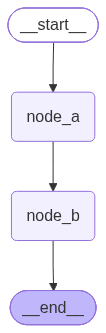

In [3]:
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking":{
            "type":"disabled"
        }
    }
)

#1. 状態を定義
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str

#2. ノードを定義
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"{state['topic']}をテーマにした詩を書いてください"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"{state['topic']}をテーマにしたジョークを書いてください"]).content
    return {
        "joke": joke
    }

#3. グラフを構築
builder = StateGraph(state_schema=OverAllState)

builder.add_node(node_a)
builder.add_node(node_b)

builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_b",END)

graph = builder.compile()
res = graph.invoke({"topic": "三毛猫"})
print(res)

from IPython.display import display
display(graph)


{
    'topic': '三毛猫',
    'poem': '## 
三毛猫の午後\n\n君の毛並みは\n雨上がりの街の\nアスファルトに映る\n信号機の色\n\n白は\n冬の初めの\nためらいの色\nオ
レンジは\n夏の終わりの\n諦めの色\n黒は\n夜の始まりの\n約束の色\n\n三つの季節を\n一枚の皮に抱えて\n君は\n今日も\n屋
根の上で\nバランスを\nとりつづける\n\nしっぽの先で\n数えるのは\n通り過ぎる雲の数\n爪をといた\n玄関の柱には\n君の過
去が\n螺旋状に刻まれて\n\nねえ\n三毛猫よ\n君の歩く道には\nいつも\n三つの影が\nついてくる\n\nひとつは昨日の記憶\nひ
とつは明日の予感\nそして\nもうひとつは\n誰も知らない\n今の君の\n本当の色\n\n日暮れが\n君の背中を\nゆっくりと\n塗り
替えていく\n三色の夕暮れが\n君の中で\n溶け合って\n\nやがて\nすべてが\nひとつの\n夜になるまで\n君は\n静かに\n目を閉
じている',
    'joke': '三毛猫のジョーク、いくつかお届けしますね。\n\n---\n\n**1. 
占いの話**\n\n三毛猫が占い師のところへ行きました。\n\n「先生、私の運勢を見てください」\n\n占い師は水晶玉をじっと見
つめて言いました。\n\n「うーん…あなたはね、これから『白』と『黒』と『茶』、それぞれの道が待っているわ」\n\n三毛猫、
首をかしげて：\n\n「それって、つまり…何色にでもなれるってこと？」\n\n占い師、真剣な顔で：\n\n「いいえ、ただ単にあな
たが落ち着きがないってことよ」\n\n---\n\n**2. 
ダジャレ編**\n\n「三毛猫が海で溺れてる！」\n\n「大丈夫、ちゃんと『三毛』（三毛＝毛が三色）あるから、浮くんじゃない
？」\n\n「いや、それは『毛』があるから浮くんであって、色の問題じゃないだろ！」\n\n---\n\n**3. 
動物会議**\n\n動物たちの集会で、三毛猫がスピーチを始めました。\n\n「我々猫族は、色の違いで差別されてはならない！ 
白い猫も黒い猫も茶色い猫も、みんな同じ猫ではないか！」\n\nすると、後ろの方から一匹の黒猫が：\n\n「じゃあ、なんでお
前、三色も使ってるんだよ。俺は一色で十分だ」\n\n---\n\n**4. 
飼い主の悩み**\n\n飼い主が三毛猫に言いました。\n\n「あなた、毛色が三色もあるから、毎日どれで遊べばいいか迷っちゃう
よ」\n\n三毛猫、ため息混じりに：\n\n「私もよ。今日はどの色でお願いしようか、朝からずっと迷ってるの」\n\n---\n\n**5.
 
一番シンプルなやつ**\n\n「三毛猫が三匹いるんだけど、何色に見える？」\n\n「そりゃあ、ミケミケミケだろ」\n\n---\n\nい
かがでしたか？ 三毛猫は「三色」という設定だけで結構遊べますね。お好みのツボがあれば幸いです。'
}

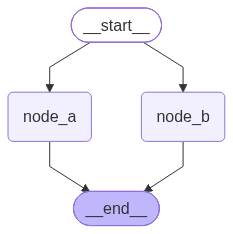

In [5]:
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking":{
            "type":"disabled"
        }
    }
)

#1. 状態を定義
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str

#2. ノードを定義
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"{state['topic']}をテーマにした詩を書いてください"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"{state['topic']}をテーマにしたジョークを書いてください"]).content
    return {
        "joke": joke
    }

#3. グラフを構築
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_edge(START,"node_a")
builder.add_edge(START,"node_b")

builder.add_edge("node_b",END)
builder.add_edge("node_a",END)

graph = builder.compile()
res = graph.invoke({"topic": "三毛猫"})
print(res)

from IPython.display import display
display(graph)
